<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання**: Реалізувати алгоритм методу опорних векторів, використавши один з датасетів https://www.kaggle.com/datasets?search=security, оцінити точність та фактори, від яких вона може залежати на прикладі обраного датасету.

**Теорія**: Модель із використанням методу опорних векторів (SVM, Support Vector Machine) – це один із алгоритмів для класифікації, який шукає гіперплощину, що максимально розділяє різні класи даних. Основна ідея методу полягає в тому, щоб знайти таку гіперплощину в багатовимірному просторі, яка створює найбільший відступ між класами, де підтримуючі вектори – це ті точки, які знаходяться найближче до гіперплощини і визначають її положення. Метод також може працювати для нелінійних даних, використовуючи ядрові функції, що дозволяє проектувати вихідні дані в простір вищої розмірності, де класи стають лінійно роздільними.

<hr>

### 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score 

### 2. Завантаження даних

In [2]:
df = pd.read_csv('./Android_Malware.csv')
df.shape 

(29332, 87)

### 3. Огляд даних

In [3]:
df.sample(5)

,android.permission.GET_ACCOUNTS,com.sonyericsson.home.permission.BROADCAST_BADGE,android.permission.READ_PROFILE,android.permission.MANAGE_ACCOUNTS,android.permission.WRITE_SYNC_SETTINGS,android.permission.READ_EXTERNAL_STORAGE,android.permission.RECEIVE_SMS,com.android.launcher.permission.READ_SETTINGS,android.permission.WRITE_SETTINGS,com.google.android.providers.gsf.permission.READ_GSERVICES,...,com.android.launcher.permission.UNINSTALL_SHORTCUT,com.sec.android.iap.permission.BILLING,com.htc.launcher.permission.UPDATE_SHORTCUT,com.sec.android.provider.badge.permission.WRITE,android.permission.ACCESS_NETWORK_STATE,com.google.android.finsky.permission.BIND_GET_INSTALL_REFERRER_SERVICE,com.huawei.android.launcher.permission.READ_SETTINGS,android.permission.READ_SMS,android.permission.PROCESS_INCOMING_CALLS,Result
1206,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
23883,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
9731,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
21618,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
11295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29332 entries, 0 to 29331
Data columns (total 87 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   android.permission.GET_ACCOUNTS                                                29332 non-null  int64
 1   com.sonyericsson.home.permission.BROADCAST_BADGE                               29332 non-null  int64
 2   android.permission.READ_PROFILE                                                29332 non-null  int64
 3   android.permission.MANAGE_ACCOUNTS                                             29332 non-null  int64
 4   android.permission.WRITE_SYNC_SETTINGS                                         29332 non-null  int64
 5   android.permission.READ_EXTERNAL_STORAGE                                       29332 non-null  int64
 6   android.permission.RECEIVE_SMS        

### 4. Попередня обробка даних¶

In [5]:
df.dropna()
df.shape

(29332, 87)

### 5. Розділення на навчальні та тестові дані

In [6]:
X = df.drop(['Result'], axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

### 6. Стандартизація даних

In [7]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train) 
scaled_X_test = scaler.transform(X_test)

###  7. Навчання моделі опорних векторів

In [8]:
model = SVC(C=10, gamma=1.0, kernel='linear') 
model.fit(scaled_X_train, y_train)

SVC(C=10, gamma=1.0, kernel='linear')

### 8. Прогнозування

In [9]:
y_pred = model.predict(scaled_X_test)

### 9. Оцінка моделі¶

In [10]:
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      2950
           1       0.96      0.96      0.96      2917

    accuracy                           0.96      5867
   macro avg       0.96      0.96      0.96      5867
weighted avg       0.96      0.96      0.96      5867

Confusion Matrix:
 [[2822  128]
 [ 119 2798]]


### 10. Візуалізація результатів

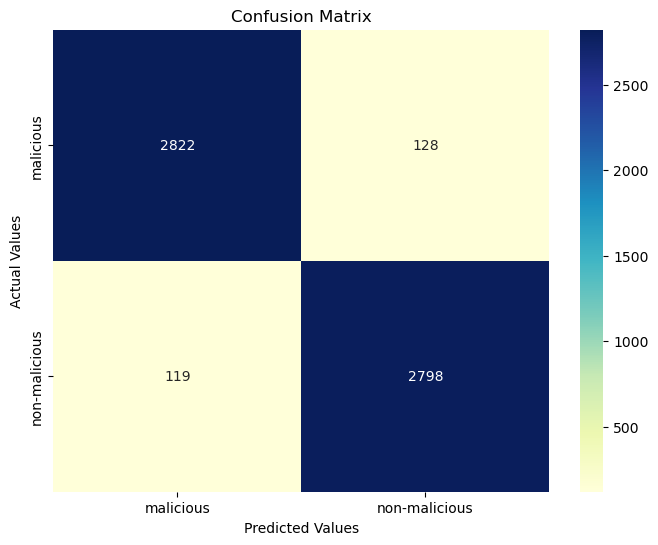

In [11]:
class_names = ['malicious', 'non-malicious']

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

<hr>

### * Пошук оптимальних параметрів для покращення точності моделі

- Ігнорування попереджень

In [12]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

- Створення сітки

In [13]:
param_grid = {'C': [1, 10, 100], 
              'gamma': [1, 0.1, 0.01], 
              'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit=True)
grid.fit(scaled_X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['rbf']})

* Огляд параметрів

In [14]:
grid.best_params_

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

In [15]:
grid.best_estimator_

SVC(C=100, gamma=0.01)

* Прогнозування

In [16]:
grid_predictions=grid.predict(scaled_X_test)

* Оцінка моделі

In [17]:
report = classification_report(y_test, grid_predictions)
conf_matrix = confusion_matrix(y_test, grid_predictions)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      2950
           1       0.98      0.96      0.97      2917

    accuracy                           0.97      5867
   macro avg       0.97      0.97      0.97      5867
weighted avg       0.97      0.97      0.97      5867

Confusion Matrix:
 [[2884   66]
 [ 119 2798]]


* Побудова графіків

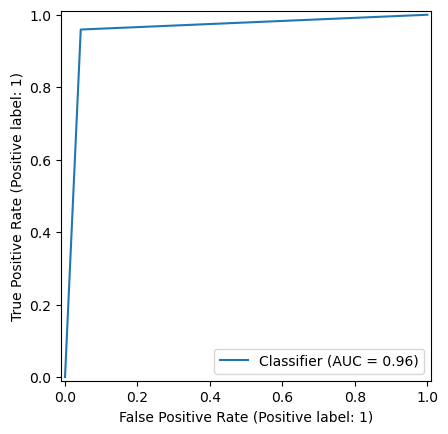

In [18]:
svc_disp=RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

In [19]:
print("Area Under the Curve:", round(roc_auc_score(y_test, grid_predictions), 3))

Area Under the Curve: 0.968


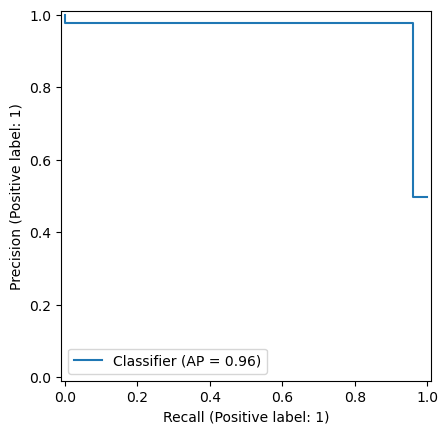

In [20]:
svc_disp=PrecisionRecallDisplay.from_predictions(y_test, grid_predictions)
plt.show()